# 1D AMT Forward Model

In [1]:
#Imports

import numpy as np
from simpeg.electromagnetics import natural_source as nsem
from simpeg import maps
import matplotlib.pyplot as plt
import matplotlib
from simpeg.utils import plot_1d_layer_model
from discretize import TensorMesh
import warnings
warnings.filterwarnings("ignore")
from simpeg import (
    maps, data, data_misfit, regularization,
    optimization, inverse_problem, inversion, directives,utils,
)
from ipywidgets import widgets, interact
from pathlib import Path
from mtpy.core.mt_collection import MTCollection
mtc = MTCollection()
import mtpy as mt
import utm
import matplotlib.gridspec as gridspec
import scipy


#Solver for Mac
from pymatsolver import Mumps

matplotlib.rcParams['font.size'] = 14

### Geological Figure of Uranium Ore Body (Tuncer, 2017)

![My Image](Geological_Figures.png)

### Defining Properties and Plotting Layer Model

Text(0.5, 1.0, 'Depth vs. Sigma')

<Figure size 1000x500 with 0 Axes>

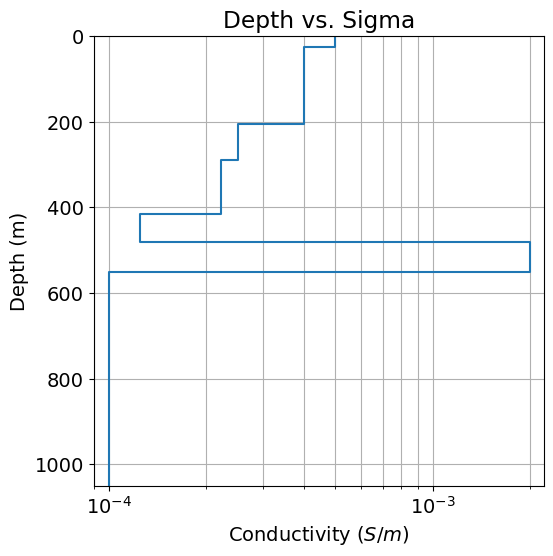

In [2]:
#Geological properties
layer_thicknesses = np.array([25, 180, 85, 125, 65,70,500]) #Thicknesses were obtained from Tuncer, pg. 16
sigma = 1/np.r_[2000.,2500., 4000., 4500.,8000,500,10000]# in S/m # Unknown resistivities/Conductivities had to be inferred Tuncer Fig. 3-17 borehole data


################
# No Ore
#sigma = 1/np.r_[2000.,2500., 4000., 4500.,8000,8000,10000]# in S/m # Unknown resistivities/Conductivities had to be inferred Tuncer Fig. 3-17 borehole data
################


#Survey Properties
frequencies = np.r_[7.68*10**3, 5.12*10**3, 3.84*10**3, 1.28*10**3,
    9.59*10**2, 6.4*10**2, 4.64*10**2, 3.36*10**2, 2.4*10**2, 1.77*10**2, 1.28*10**2,
    9.699*10**1,8.1*10**1,7.1*10**1,6.1*10**1,5.1*10**1,4.1*10**1,3.275*10**1,2.225*10**1,1.512*10**1,1.025*10**1,
    6.937,4.875]  # frequencies in Hz # Obtained from Cameco Data, Line 304

#Obtaining max and min skin depths given frequencies and expected resisitivies
min_skin_depth = 503*np.sqrt(np.min(1/sigma)/frequencies.max())
max_skin_depth = 503*np.sqrt(np.max(1/sigma)/frequencies.min())



#Plotting 1D Layer Model for visualization
fig = plt.figure(figsize=(10, 5))
ax1 = plot_1d_layer_model(layer_thicknesses, sigma) # figure has base value at log plot
ax1.grid(which="both")
ax1.set_xlabel(r"Conductivity ($S/m$)")
ax1.set_title('Depth vs. Sigma')


In [3]:
#Plotting Skin Depths
print(f'Max Skin Depth: {max_skin_depth}')
print(f'Min Skin Depth: {min_skin_depth}')

Max Skin Depth: 22781.413926989266
Min Skin Depth: 128.34305631457696


In [4]:
min(frequencies)

np.float64(4.875)

### Defining Mesh

Text(0.5, 0, 'Depth (n)')

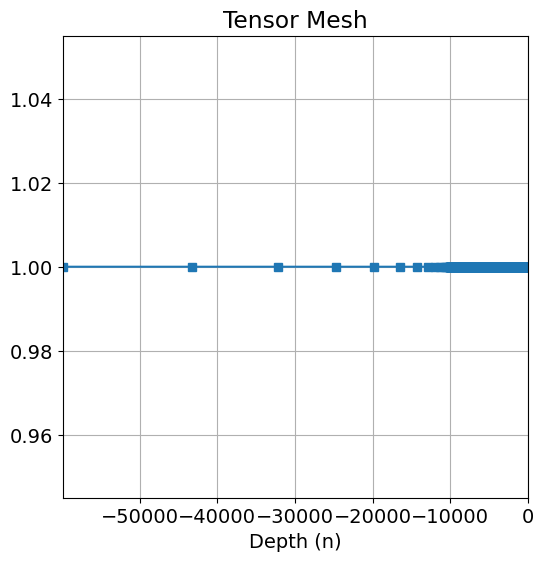

In [5]:
dx = 5  # base cell width x
ncx = 10000 * 1/dx  # number of core mesh cells in x
exp_x = 1.5  # expansion rate of padding cells in x
npad_x = int(np.ceil(np.log(1+(max_skin_depth-600) * (exp_x-1)/dx)/np.log(exp_x)))  # number of padding cells in x

# Use a list of tuples to define cell widths in each direction. Each tuple
# contains the cell width, number of cells and the expansion factor. A
# negative sign is used to indicate an interval where cells widths go
# from largest to smallest.
hx = [(dx, npad_x, -exp_x), (dx, ncx)] #, (dx, npad_x, exp_x)]

# We can use flags 'C', '0' and 'N' to shift the xyz position of the mesh
# relative to the origin
mesh = TensorMesh([hx], x0 = "N")

# We can apply the plot_grid method and output to a specified axes object
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)
mesh.plot_grid(ax=ax, nodes="True")
ax.set_xbound(mesh.x0[0], mesh.x0[0] + np.sum(mesh.h[0]))
ax.set_title("Tensor Mesh")
ax.set_xlabel('Depth (n)')

In [6]:
#Printing Mesh Values
mesh

TensorMesh: 2,020 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x   2020    -59,863.85          0.00      5.00 16,626.28    1.50

Mesh is ~2x the maximum skin depth and the cells that represent the halfspace dont represent the vast majority of cells!

In [7]:
#Defining the sigma backround as the highest conducivity layer (overburden)
sigma_background = 1/4000

#Creating a model (ie. creating an array the same size as the mesh to represent each of the mesh's cells conductivity)
model = np.ones(mesh.n_cells) * sigma_background  # np.zeros(len(x_cells)) 


#Defining Layer Depths
layer_depths = np.array([layer_thicknesses[0],
                         layer_thicknesses[0] + layer_thicknesses[1],
                         layer_thicknesses[0] + layer_thicknesses[1] + layer_thicknesses[2],
                         layer_thicknesses[0] + layer_thicknesses[1] + layer_thicknesses[2] + layer_thicknesses[3],
                         layer_thicknesses[0] + layer_thicknesses[1] + layer_thicknesses[2] + layer_thicknesses[3] + layer_thicknesses[4], 
                         layer_thicknesses[0] + layer_thicknesses[1] + layer_thicknesses[2] + layer_thicknesses[3] + layer_thicknesses[4] + layer_thicknesses[5]])

    
# Defining indexes for layer depths/ depths of separations between layers
layer_1_model = (mesh.cell_centers >= -layer_depths[0])
layer_2_model = (mesh.cell_centers < -layer_depths[0]) & (mesh.cell_centers >= -layer_depths[1])
layer_3_model = (mesh.cell_centers < -layer_depths[1]) & (mesh.cell_centers >= -layer_depths[2])
layer_4_model = (mesh.cell_centers < -layer_depths[2]) & (mesh.cell_centers >= -layer_depths[3])
layer_5_model = (mesh.cell_centers < -layer_depths[3]) & (mesh.cell_centers >= -layer_depths[4])
layer_6_model_ore_body = (mesh.cell_centers < -layer_depths[4]) & (mesh.cell_centers >= -layer_depths[5])
layer_7_model = (mesh.cell_centers < -layer_depths[5])



#Assigning conductivities to each layer per indexes
model[layer_1_model] = sigma[0]
model[layer_2_model] = sigma[1]
model[layer_3_model] = sigma[2]
model[layer_4_model] = sigma[3]
model[layer_5_model] = sigma[4]
model[layer_6_model_ore_body] = sigma[5]
model[layer_7_model] = sigma[6]

print(model)


[0.0001 0.0001 0.0001 ... 0.0005 0.0005 0.0005]


In [8]:
len(model[layer_1_model]) + len(model[layer_2_model])+ len(model[layer_3_model])+ len(model[layer_4_model])+len( model[layer_5_model]) +len(model[layer_6_model_ore_body] )

110

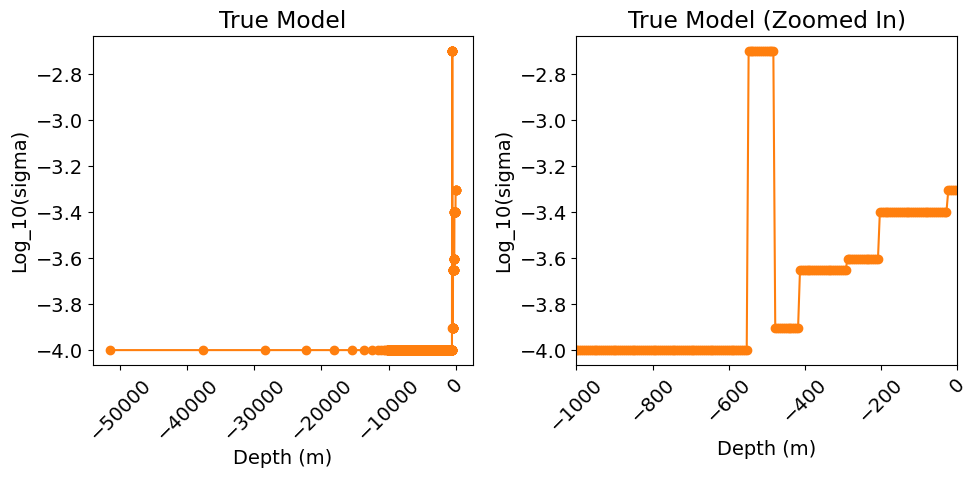

In [9]:
#Plotting Mesh with True Model
fig, ax = plt.subplots(1,2, figsize = (10,5))
mesh.plot_image(np.log10(model), ax = ax[0])
ax[0].set_title('True Model')
ax[0].set_xlabel('Depth (m)')
ax[0].set_ylabel('Log_10(sigma)')
ax[0].tick_params(axis='x', rotation=45)

mesh.plot_image(np.log10(model), ax = ax[1])
ax[1].set_title('True Model (Zoomed In)')
ax[1].set_xlabel('Depth (m)')
ax[1].set_ylabel('Log_10(sigma)')
ax[1].set_xlim(-1000,0)
ax[1].tick_params(axis='x', rotation=45)
fig.tight_layout()

### Setting up 1D MT Simulation

In [10]:

############
#Creating Sigma map
sigma_map = maps.IdentityMap(nP=mesh.nC)# * wire_map.sigma # Extracting sigma from wire_map

#Setting up RX locations 
rx_loc_single = np.array([[0]])

#Receivers list
receivers_list = [
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="real"),  #Only off diagonal components for 1D
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="imag"),

    nsem.receivers.Impedance(rx_loc_single, orientation="yx", component="real"),
    nsem.receivers.Impedance(rx_loc_single, orientation="yx", component="imag"),
]

source_list = []
for freq in frequencies:
    source_list.append(nsem.sources.Planewave(receivers_list, freq)) # Setting sources as plane waves at each specified frequencies 

survey = nsem.survey.Survey(source_list) #Creating survey object with given sources form source_list

#Creating simulation object
simulation = nsem.Simulation1DElectricField(mesh,
    survey=survey, 
    sigmaMap=sigma_map,
    solver = Mumps)

#Setting true model as previously obtained model
true_model = model

#creating predicted data on basis of true model + receivers, frequencies, orientations, etc.
dpred = simulation.dpred(true_model)
dobs = dpred # Saving for inversion purposes
dpred = dpred.reshape(len(frequencies),4)

Zxy = dpred[:,0]+ 1j* dpred[:,1] # Defining components for ease of use for future parts
Zyx = dpred[:,2] + 1j*dpred[:,3]

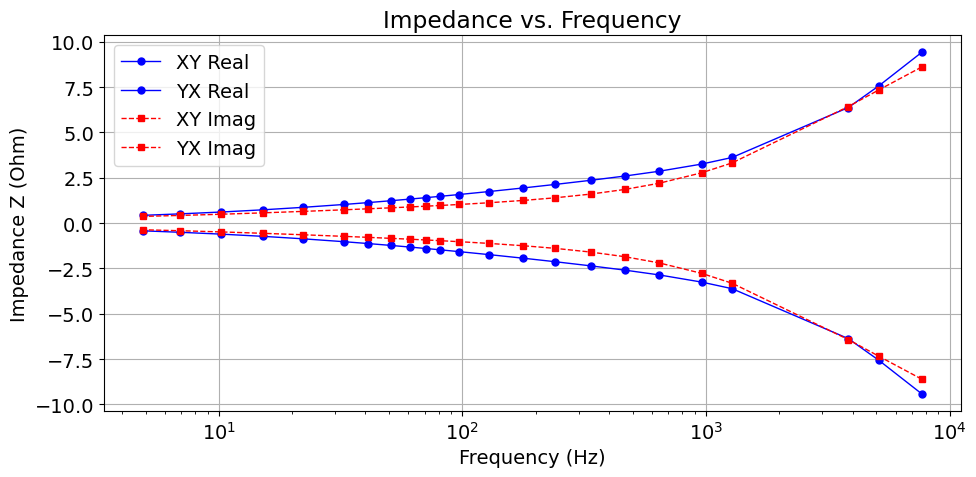

In [11]:
fig, ax = plt.subplots(1,1,figsize=(10, 5))

#Plotting Real Component XY and YX 
ax.semilogx(frequencies, dpred[:,0], "b-o", lw=1, ms=5, label = 'XY Real')
ax.semilogx(frequencies, dpred[:,2], "b-o", lw=1, ms=5, label = 'YX Real')

#Pting Imag Component XY and YX 
ax.semilogx(frequencies, dpred[:,1], "r--s", lw=1, ms=5, label = 'XY Imag')
ax.semilogx(frequencies, dpred[:,3], "r--s", lw=1, ms=5, label = 'YX Imag')

ax.grid()
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Impedance Z (Ohm)")
ax.set_title("Impedance vs. Frequency")
ax.legend

ax.legend()


fig.tight_layout()


In [12]:
#Defining Values to plot apparent resisitivity and phase
omega = 2*np.pi* frequencies

#Computing Apparent resisitvity and phase
apparent_rho = (np.abs(Zxy)**2)/ (scipy.constants.mu_0 * omega)
phase = np.rad2deg(np.arctan2( np.imag(Zxy),np.real(Zxy)))

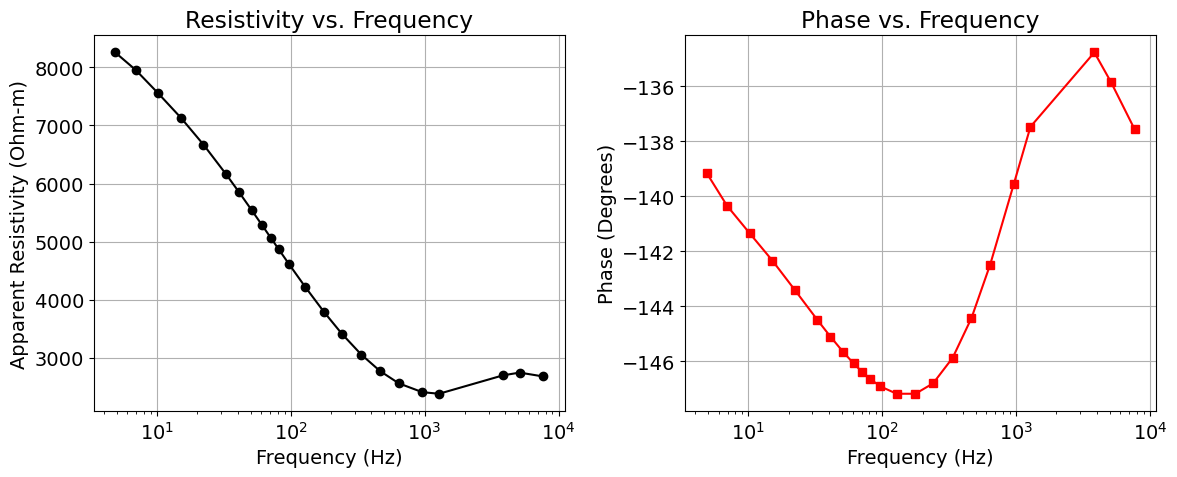

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

#Plotting Apparent Resisitivty
ax[0].semilogx(frequencies, apparent_rho, 'k-o')
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Apparent Resistivity (Ohm-m)")
ax[0].set_title('Resistivity vs. Frequency')
ax[0].grid()

# Plotting Phase
ax[1].semilogx(frequencies, phase, 'r-s')
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Phase (Degrees)")
ax[1].set_title('Phase vs. Frequency')
ax[1].grid()

plt.tight_layout()


### Saving Forward Model Data

In [14]:
### UNCOMMENT WHEN CHANGING ORE SIGMA
# np.save("Forward_Data/Observed_Forward_Model_Data_Original.npy", dobs)
# np.save("Forward_Data/Observed_Forward_Model_Data_Reshaped.npy", dpred)


### UNCOMMENT WHEN CHANGING NO ORE SIGMA
# np.save("Forward_Data/Observed_Forward_Model_Data_Original_no_ore.npy", dobs)
# np.save("Forward_Data/Observed_Forward_Model_Data_Reshaped_no_ore.npy", dpred)

